# Partie I — MLP sur Adult Income

## 01. Importation des bibliothèques

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import copy

import seaborn as sns


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "report").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURES_DIR = PROJECT_ROOT / "report" / "figures" / "MLP"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(filename, fig=None, dpi=300):
    figure = fig if fig is not None else plt.gcf()
    output_path = FIGURES_DIR / filename
    figure.savefig(output_path, dpi=dpi, bbox_inches="tight")
    return output_path

##  02. Reproductibilité et device CPU/GPU
Cette cellule prépare les bases de notre modèle en remplissant deux objectifs principaux :

1. **Assurer la reproductibilité (`set_seed`)** : En fixant la "graine" (seed) pour Python, NumPy et PyTorch, nous garantissons que les processus aléatoires (comme l'initialisation des poids ou le mélange des données) seront exactement les mêmes à chaque exécution. Cela rend les résultats constants et comparables.
2. **Assigner le matériel de calcul (`device`)** : Le code détecte automatiquement si une carte graphique (GPU / CUDA) est disponible pour accélérer massivement les calculs. Si aucune n'est trouvée, il utilisera le processeur classique (CPU) par défaut.

In [3]:
SEED = 42 
def set_seed(seed = 42): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 03. Chargement du dataset Adult Income

In [4]:
adult = fetch_openml(name="adult", version=2, as_frame=True)

X = adult.data.copy()
y = adult.target.copy()

print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)
X.head()

Dimensions X : (48842, 14)
Dimensions y : (48842,)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


## 04. Compréhension et analyse du dataset

In [5]:
print("Colonnes du dataset :")
print(X.columns.tolist())

print("\nTypes des variables :")
print(X.dtypes)

Colonnes du dataset :
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Types des variables :
age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
dtype: object


In [6]:
y.dtypes

CategoricalDtype(categories=['<=50K', '>50K'], ordered=False, categories_dtype=str)

In [7]:
display(X.info())

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


None

In [8]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numériques :", numeric_features)
print("Nombre :", len(numeric_features))

print("\nVariables catégorielles :", categorical_features)
print("Nombre :", len(categorical_features))

Variables numériques : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Nombre : 6

Variables catégorielles : ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Nombre : 8


In [9]:
display(y.value_counts(normalize=True) * 100)

class
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

In [10]:
print("\nDistribution de la variable cible :")
df = y.value_counts().rename_axis('class').reset_index(name='count')
df['percentage %'] = (df['count'] / df['count'].sum() * 100).round(2)
display(df)


Distribution de la variable cible :


,class,count,percentage %
0,<=50K,37155,76.07
1,>50K,11687,23.93


In [11]:
print("Valeurs manquantes classiques :")
print(X.isna().sum())

Valeurs manquantes classiques :
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64


In [12]:
print(f"\nValeurs dupliquées : {X.duplicated().sum()}")
print(f"\nValeurs manquantes (y compris les '?') : {X.isnull().sum().sum()}")


Valeurs dupliquées : 57

Valeurs manquantes (y compris les '?') : 6465


In [13]:
display(X.describe(include='all'))

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
count,48842.000000,46043,4.884200e+04,48842,48842.000000,48842,46033,48842,48842,48842,48842.000000,48842.000000,48842.000000,47985
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN


### Distribution des classes
On regarde `y` qui contient la cible et permet de verifier l'equilibre des classes.
- ` remarque : On evite  ``X.value_counts()`` sur la matrice de features: sur un tableau tres large, cela peut exploser la memoire. `

In [14]:
# Ne pas appliquer value_counts sur X : sur une matrice tres large, cela peut provoquer un MemoryError.
display(y.value_counts(normalize=True) * 100)

class
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

## 05. Nettoyage des données

In [15]:
print("Valeurs manquantes classiques :")
print(X.isna().sum())

print("\nRecherche des '?' dans les colonnes catégorielles :")
for col in categorical_features:
    count_question = (X[col].astype(str).str.strip() == "?").sum()
    print(col, ":", count_question)

Valeurs manquantes classiques :
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

Recherche des '?' dans les colonnes catégorielles :
workclass : 0
education : 0
marital-status : 0
occupation : 0
relationship : 0
race : 0
sex : 0
native-country : 0


In [16]:
df = X.copy()
df["income"] = y

# Supprimer les lignes contenant des valeurs manquantes
df_clean = df.dropna().copy()

# Nettoyer les espaces seulement après suppression des NaN
for col in df_clean.select_dtypes(include=["object", "category"]).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print("Dimensions avant nettoyage :", df.shape)
print("Dimensions après nettoyage :", df_clean.shape)

print("\nValeurs manquantes après nettoyage :")
print(df_clean.isna().sum())


Dimensions avant nettoyage : (48842, 15)
Dimensions après nettoyage : (45222, 15)

Valeurs manquantes après nettoyage :
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


### Encodage de la cible :

In [17]:
print("\nValeurs uniques dans la variable cible :")
print(df_clean["income"].unique().tolist())



Valeurs uniques dans la variable cible :
['<=50K', '>50K']


In [18]:
print("\nDistribution de la variable cible après nettoyage :")
display(pd.DataFrame(df_clean["income"].value_counts()))

df_clean["target"] = df_clean["income"].map({
    "<=50K": 0,
    ">50K": 1
})
print("\nDistribution de la variable cible après encodage :")
display(pd.DataFrame(df_clean["target"].value_counts()))


Distribution de la variable cible après nettoyage :


,count
income,
<=50K,34014
>50K,11208



Distribution de la variable cible après encodage :


,count
target,
0,34014
1,11208


### Séparation features / target :

In [19]:
print(df_clean.columns.tolist())
df_clean.head()

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'target']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K,0


In [20]:
X_clean = df_clean.drop(columns=["income", "target"])
y_clean = df_clean["target"].astype(int)

numeric_features = X_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_clean.select_dtypes(include=["object", "category","string"]).columns.tolist()

display("Variables numériques :", numeric_features)
display("Variables catégorielles :", categorical_features)

'Variables numériques :'

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

'Variables catégorielles :'

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

## 06. Split train / validation / test

`Important : on fait le split avant d’entraîner le préprocesseur pour éviter la fuite de données.`

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean,
    y_clean,
    test_size=0.30,
    random_state=SEED,
    stratify=y_clean
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train :", X_train.shape, y_train.shape)
print("Validation :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train : (31655, 14) (31655,)
Validation : (6783, 14) (6783,)
Test : (6784, 14) (6784,)


In [22]:
print("Distribution train ( % ) :")
display(y_train.value_counts(normalize=True) * 100 )

print("\nDistribution validation ( % ) :")
display(y_val.value_counts(normalize=True) * 100 )

print("\nDistribution test ( % ) :")
display(y_test.value_counts(normalize=True) * 100 )

Distribution train ( % ) :


target
0    75.214026
1    24.785974
Name: proportion, dtype: float64


Distribution validation ( % ) :


target
0    75.217455
1    24.782545
Name: proportion, dtype: float64


Distribution test ( % ) :


target
0    75.221108
1    24.778892
Name: proportion, dtype: float64

## 07. Prétraitement : encodage et normalisation

version avec normalisation :

On va standardiser les variables numériques, encoder les variables textuelles et applique ces changements sur nos ensembles d'entraînement, de validation et de test.

In [23]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    print("Warning: 'sparse_output' parameter not available. Using 'sparse=False' instead.")
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", onehot, categorical_features)
    ]
)

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)
X_test_scaled = preprocessor_scaled.transform(X_test)

print("X_train après prétraitement :", X_train_scaled.shape)
display(pd.DataFrame(X_train_scaled).head())


X_train après prétraitement : (31655, 104)


,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
0,0.336395,-0.516254,1.510203,-0.148057,-0.2184,0.747279,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.770641,0.524995,1.120307,13.081812,-0.2184,-0.084400,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.324310,0.808359,-0.049379,-0.148057,-0.2184,-0.084400,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.493957,0.117601,-1.219065,-0.148057,-0.2184,-0.084400,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.946877,-0.439026,-0.049379,-0.148057,-0.2184,-0.084400,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Version sans normalisation, pour l’expérience comparative :

In [24]:
try:
    onehot_no_scale = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    print("Warning: 'sparse_output' parameter not available. Using 'sparse=False' instead.")
    onehot_no_scale = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_no_scale = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", onehot_no_scale, categorical_features)
    ]
)

X_train_no_scale = preprocessor_no_scale.fit_transform(X_train)
X_val_no_scale = preprocessor_no_scale.transform(X_val)
X_test_no_scale = preprocessor_no_scale.transform(X_test)

print("X_train sans normalisation :", X_train_no_scale.shape)

X_train sans normalisation : (31655, 104)


## 08. Création des Dataset et DataLoader PyTorch

### 🧠 Création du Dataset PyTorch personnalisé

Cette cellule définit une classe personnalisée appelée `AdultIncomeDataset`. Elle hérite de la classe `Dataset` de **PyTorch**. 
Son but est de convertir nos tableaux de données (NumPy/Pandas) en objets compatibles avec les outils d'entraînement de PyTorch (comme les `DataLoader`).

La classe surcharge les **trois méthodes indispensables** imposées par PyTorch :

1. **`__init__(self, X, y)` (Initialisation) :**
   * Reçoit les fonctionnalités de prédiction (`X`) et la variable cible (`y`).
   * Convertit les données en **Tenseurs PyTorch** de type décimal (`torch.float32`).
   * Utilise `.view(-1, 1)` sur `y` pour s'assurer que la variable cible a la forme d'une colonne verticale (vecteur 2D), ce qui est obligatoire pour calculer les fonctions de perte (*loss*) en classification binaire.

2. **`__len__(self)` (Taille) :**
   * Renvoie le nombre total d'exemples (lignes) présents dans le jeu de données. 
   * Permet à PyTorch de savoir quand une époque d'entraînement est terminée.

3. **`__getitem__(self, idx)` (Extraction) :**
   * Permet de récupérer un exemple précis (`X[idx]`) associé à son étiquette (`y[idx]`) via son index.
   * Cette méthode est appelée automatiquement en arrière-plan pour charger les données par petits groupes (mini-batches).


In [25]:
class AdultIncomeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.to_numpy(), dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### 📦 Préparation des chargeurs de données (DataLoader) et taille d'entrée

Cette cellule prépare l'alimentation du modèle PyTorch en découpant les données et en configurant la structure du futur réseau de neurones.

#### 1. Configuration des Mini-Batches
* **`BATCH_SIZE = 128`** : Définit la taille des lots. Le modèle ne va pas analyser tout le jeu de données d'un coup, mais par groupes de 128 lignes. Cela stabilise l'entraînement et évite de saturer la mémoire (RAM).

#### 2. Instanciation des Datasets
* Les données d'entraînement (`scaled`), de validation et de test sont converties en objets PyTorch en utilisant la classe personnalisée `AdultIncomeDataset` créée à l'étape précédente.

#### 3. Création des `DataLoader`
Le `DataLoader` gère la logique d'envoi des données au modèle durant l'apprentissage :
* **`train_loader` (`shuffle=True`)** : Mélange aléatoirement les données d'entraînement à chaque époque. C'est indispensable pour que le modèle n'apprenne pas l'ordre des lignes par cœur et généralise mieux.
* **`val_loader` & `test_loader` (`shuffle=False`)** : Ne mélangent pas les données. Pour l'évaluation, l'ordre n'a pas d'importance, désactiver le mélange permet de gagner du temps de calcul.

#### 4. Dimension d'entrée du réseau (`input_dim`)
* **`X_train_scaled.shape[1]`** : Récupère le nombre exact de colonnes finales après notre étape de prétraitement (StandardScaler + OneHotEncoder). 
* Cette variable `input_dim` est cruciale car elle dictera la taille de la **toute première couche** de votre réseau de neurones.


In [26]:
BATCH_SIZE = 128

train_dataset = AdultIncomeDataset(X_train_scaled, y_train)
val_dataset = AdultIncomeDataset(X_val_scaled, y_val)
test_dataset = AdultIncomeDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train_scaled.shape[1]
print("Nombre de features après encodage :", input_dim)

Nombre de features après encodage : 104


DataLoaders sans normalisation :

In [27]:
train_dataset_no_scale = AdultIncomeDataset(X_train_no_scale, y_train)
val_dataset_no_scale = AdultIncomeDataset(X_val_no_scale, y_val)
test_dataset_no_scale = AdultIncomeDataset(X_test_no_scale, y_test)

train_loader_no_scale = DataLoader(train_dataset_no_scale, batch_size=BATCH_SIZE, shuffle=True)
val_loader_no_scale = DataLoader(val_dataset_no_scale, batch_size=BATCH_SIZE, shuffle=False)
test_loader_no_scale = DataLoader(test_dataset_no_scale, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
# Vérification d'un batch PyTorch
X_batch, y_batch = next(iter(train_loader))

print("X_batch shape :", X_batch.shape)
print("y_batch shape :", y_batch.shape)
print("X_batch dtype :", X_batch.dtype)
print("y_batch dtype :", y_batch.dtype)

assert X_batch.shape[1] == input_dim
assert y_batch.shape[1] == 1
assert X_batch.dtype == torch.float32
assert y_batch.dtype == torch.float32

print("Vérification Dataset/DataLoader réussie.")

X_batch shape : torch.Size([128, 104])
y_batch shape : torch.Size([128, 1])
X_batch dtype : torch.float32
y_batch dtype : torch.float32
Vérification Dataset/DataLoader réussie.


## 09. Définition des modèles MLP
On a deux methodes pour construire notre réseau de neurone
- nn.Sequential permet d’enchaîner les couches simplement et rapidement (pas compatible pour les architectures complexes)
- une classe personnalisée héritant de nn.Module offre plus de flexibilité avec une méthode forward().
### Version nn.Sequential

In [29]:
def build_mlp_sequential(input_dim):
    model = nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 1)
    )
    return model

### Version classe personnalisée

In [30]:
class MLPCustom(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.output = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        logits = self.output(x)
        return logits

## 10. Initialisation des poids

Pour initialiser les poids, on a 3 strategies : 
- **Gaussienne** (normal) : poids petits tirer au hasard selon loi normale ( courbe de Gausse), apprentissage généralement stable.
- **Constante** : mauvaise en pratique, car les neurones commencent de manière identique, ce qui crée un problème de symétrie.
- **Xavier** : cherche à stabiliser la variance du signal pendant la propagation, on calculons l'écart des valeurs aléatoires en fonction du nombre de neurones d'entrée et de sortie de la couche. Plus une couche a de neurones, plus les poids initiaux seront petits. Cela évite que les signaux mathématiques ne deviennent trop gigantesques (exploding gradients) ou minuscules (vanishing gradients) au début de l'entraînement. 


In [31]:
def init_weights(model, strategy="xavier"):
    for module in model.modules():
        if isinstance(module, nn.Linear):
            if strategy == "normal":
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.zeros_(module.bias)

            elif strategy == "constant":
                nn.init.constant_(module.weight, 1.0)
                nn.init.zeros_(module.bias)

            elif strategy == "xavier":
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

            else:
                raise ValueError("Stratégie inconnue. Choisir : normal, constant ou xavier.")

## 11. Fonctions d'entraînement et d'évaluation

In [32]:
# Cette fonction prend les logits (sortie brute du modèle) et les étiquettes vraies, et calcule l'accuracy.
def compute_accuracy_from_logits(logits, y_true):
    probs = torch.sigmoid(logits) # transformez les logits en probabilités
    preds = (probs >= 0.5).float() # convertissez les probabilités en prédictions binaires 0 ou 1
    correct = (preds == y_true).sum().item()
    total = y_true.size(0) 
    return correct / total

In [33]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0
    total_samples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad() # réinitialiser les gradients pour ne pas accumuler les erreurs du batch précédent

        logits = model(X_batch)
        loss = criterion(logits, y_batch) # calcule l'erreur du modèle

        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        running_loss += loss.item() * batch_size # loss.item() donne la valeur scalaire du loss pour le batch, on multiplie par batch_size pour obtenir la contribution totale du batch à la perte de l'époque
        running_acc += compute_accuracy_from_logits(logits, y_batch) * batch_size
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_acc = running_acc / total_samples

    return epoch_loss, epoch_acc

In [34]:
def evaluate(model, loader, criterion, device):
    # mettre le modèle en mode évaluation pour désactiver les comportements spécifiques à l'entraînement (ex: dropout)
    # on utilise 100% des neurones pour faire les prédictions, ce qui donne une évaluation plus précise des performances du modèle sur les données de validation ou de test
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    total_samples = 0
    
    #Puisque on veut juste lire le score pour evaluer et pas à modifier les neurones 
    #on va bloquer le calcule de gradients pour économiser de la mémoire et accélérer les calculs
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            batch_size = X_batch.size(0)
            #loss.item() est la moyenne du loss pour le batch, 
            #on multiplie par batch_size pour obtenir la contribution totale du batch à la perte de l'époque
            # d un autre terme on accumule la perte et l'accuracy pour tous les batches
            running_loss += loss.item() * batch_size
            running_acc += compute_accuracy_from_logits(logits, y_batch) * batch_size
            total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_acc = running_acc / total_samples

    return epoch_loss, epoch_acc

In [35]:
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, device="cpu"):
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss() # fct de perte  pour classification binaire, combine un Sigmoid et un Binary Cross Entropy Loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # reçoit les paramètres du modèle et le taux d'apprentissage et adapte automatiquement la vitesse de réglafz pour chaque neurone

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_state_dict = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
        )

    model.load_state_dict(best_state_dict)
    return model, history

## 12. Expériences comparatives

In [36]:
EPOCHS = 20
LR = 1e-3

experiments = []
histories = {}
models = {}

### Expérience 1 — MLP Sequential + Xavier + normalisation

In [37]:
set_seed(SEED)

model_seq_xavier = build_mlp_sequential(input_dim)
init_weights(model_seq_xavier, strategy="xavier")

model_seq_xavier, history_seq_xavier = train_model(
    model_seq_xavier,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    device=device
)

histories["sequential_xavier_scaled"] = history_seq_xavier
models["sequential_xavier_scaled"] = model_seq_xavier

Epoch 01/20 | Train Loss: 0.3644 | Val Loss: 0.3288 | Train Acc: 0.8260 | Val Acc: 0.8389
Epoch 02/20 | Train Loss: 0.3225 | Val Loss: 0.3219 | Train Acc: 0.8519 | Val Acc: 0.8417
Epoch 03/20 | Train Loss: 0.3158 | Val Loss: 0.3220 | Train Acc: 0.8538 | Val Acc: 0.8462
Epoch 04/20 | Train Loss: 0.3133 | Val Loss: 0.3208 | Train Acc: 0.8542 | Val Acc: 0.8455
Epoch 05/20 | Train Loss: 0.3109 | Val Loss: 0.3206 | Train Acc: 0.8557 | Val Acc: 0.8459
Epoch 06/20 | Train Loss: 0.3082 | Val Loss: 0.3221 | Train Acc: 0.8597 | Val Acc: 0.8453
Epoch 07/20 | Train Loss: 0.3067 | Val Loss: 0.3220 | Train Acc: 0.8588 | Val Acc: 0.8459
Epoch 08/20 | Train Loss: 0.3048 | Val Loss: 0.3207 | Train Acc: 0.8583 | Val Acc: 0.8458
Epoch 09/20 | Train Loss: 0.3014 | Val Loss: 0.3210 | Train Acc: 0.8603 | Val Acc: 0.8453
Epoch 10/20 | Train Loss: 0.2998 | Val Loss: 0.3230 | Train Acc: 0.8616 | Val Acc: 0.8449
Epoch 11/20 | Train Loss: 0.2990 | Val Loss: 0.3235 | Train Acc: 0.8626 | Val Acc: 0.8462
Epoch 12/2

### Interprétation des résultats de l'entraînement pour l'expérience 1 — MLP Sequential + Xavier + normalisation

L'analyse de l'évolution des métriques (Loss et Accuracy) au fil des 20 époques permet de dresser le diagnostic suivant :

#### 1. Diagnostic global : Début de surapprentissage (*Overfitting*) léger
Le modèle présente un comportement classique où l'apprentissage se déroule parfaitement dans un premier temps, avant de commencer à mémoriser le bruit des données :
* **Évolution de la Perte (*Loss*) :** La `Train Loss` diminue de manière fluide et continue de `0.3644` à `0.2841`. Cependant, la `Val Loss` atteint son point le plus bas à l'**Époque 05 (`0.3206`)**, avant de stagner puis de remonter légèrement pour finir à `0.3295`. 
* **Évolution de la Précision (*Accuracy*) :** La `Train Acc` progresse régulièrement pour atteindre `86.86%`. En contrepartie, la `Val Acc` sature et plafonne très tôt (dès l'Époque 03) autour d'un plateau situé entre **84.5% et 84.7%**.

#### 2. Rôle du point de sauvegarde (*Checkpointing*)
Grâce à l'utilisation de `copy.deepcopy(model.state_dict())` dans notre fonction de gestion, le modèle final retenu ne sera pas celui de la dernière époque (Époque 20). 

Le script restaure automatiquement l'état de l'**Époque 05**, qui offre le meilleur compromis et la perte de validation minimale.
* **Score final de référence (Validation) :** ~84.59% d'exactitude.

#### 3. Conclusions et pistes pour les expériences comparatives
* **Points positifs :** Un score de ~84.6% sur ce jeu de données est une excellente base de départ. L'apprentissage est stable dès la première époque, ce qui valide la stratégie d'initialisation des poids et le prétraitement des données.
* **Pistes d'amélioration :** Le modèle sature vite (dès l'époque 5). Pour repousser cette limite lors de nos prochaines expériences, nous pourrons tester :
  1. Une augmentation du taux de **Dropout** (ex: `0.3` ou `0.4`) pour limiter le surapprentissage.
  2. L'ajout de régularisation L2 via le paramètre **`weight_decay`** dans l'optimiseur Adam.
  3. Une diminution du taux d'apprentissage (**Learning Rate**) à `5e-4` pour stabiliser la convergence.


### Expérience 2 — MLP Custom + Xavier + normalisation

In [38]:
set_seed(SEED)

model_custom_xavier = MLPCustom(input_dim)
init_weights(model_custom_xavier, strategy="xavier")

model_custom_xavier, history_custom_xavier = train_model(
    model_custom_xavier,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    device=device
)

histories["custom_xavier_scaled"] = history_custom_xavier
models["custom_xavier_scaled"] = model_custom_xavier

Epoch 01/20 | Train Loss: 0.3644 | Val Loss: 0.3288 | Train Acc: 0.8260 | Val Acc: 0.8389
Epoch 02/20 | Train Loss: 0.3225 | Val Loss: 0.3219 | Train Acc: 0.8519 | Val Acc: 0.8417
Epoch 03/20 | Train Loss: 0.3158 | Val Loss: 0.3220 | Train Acc: 0.8538 | Val Acc: 0.8462
Epoch 04/20 | Train Loss: 0.3133 | Val Loss: 0.3208 | Train Acc: 0.8542 | Val Acc: 0.8455
Epoch 05/20 | Train Loss: 0.3109 | Val Loss: 0.3206 | Train Acc: 0.8557 | Val Acc: 0.8459
Epoch 06/20 | Train Loss: 0.3082 | Val Loss: 0.3221 | Train Acc: 0.8597 | Val Acc: 0.8453
Epoch 07/20 | Train Loss: 0.3067 | Val Loss: 0.3220 | Train Acc: 0.8588 | Val Acc: 0.8459
Epoch 08/20 | Train Loss: 0.3048 | Val Loss: 0.3207 | Train Acc: 0.8583 | Val Acc: 0.8458
Epoch 09/20 | Train Loss: 0.3014 | Val Loss: 0.3210 | Train Acc: 0.8603 | Val Acc: 0.8453
Epoch 10/20 | Train Loss: 0.2998 | Val Loss: 0.3230 | Train Acc: 0.8616 | Val Acc: 0.8449
Epoch 11/20 | Train Loss: 0.2990 | Val Loss: 0.3235 | Train Acc: 0.8626 | Val Acc: 0.8462
Epoch 12/2

### Expérience 2 : Comparaison Sequential vs MLPCustom (Classe)

#### 1. Constat majeur : Identité stricte des résultats
L'analyse des métriques de l'Expérience 2 (`MLPCustom`) révèle des valeurs **strictement identiques** au millième près à celles obtenues lors de l'Expérience 1 (`build_mlp_sequential`) :
* **Meilleure Époque :** Époque 05 (`Val Loss : 0.3206` | `Val Acc : 84.59%`)
* **Époque Finale (20) :** `Train Loss : 0.2841` | `Val Loss : 0.3295` | `Train Acc : 86.86%` | `Val Acc : 84.68%`

#### 2. Conclusion théorique et technique
Ce résultat valide expérimentalement un concept fondamental de PyTorch : **la syntaxe d'écriture n'influence pas la performance mathématique du modèle.** 

* Qu'on utilise l'empilement rigide `nn.Sequential` ou la structure orientée objet `nn.Module` (avec les fonctions `__init__` et `forward`), l'architecture interne générée sous le capot est rigoureusement la même.
* Le graphe de calcul et le nombre de paramètres à optimiser étant identiques, l'apprentissage produit les mêmes trajectoires de convergence.

#### 3. Conclusion pour l utilisation des deux approches :
* **Quand utiliser l'approche Sequential ?** Pour des prototypes rapides et des réseaux simples en ligne droite (comme notre architecture actuelle).
* **Quand privilégier l'approche Custom ?** Dès que le projet nécessitera des architectures avancées (connexions résiduelles, branches parallèles ou injection de conditions dynamiques dans la méthode `forward`).


### Expérience 3 — MLP Custom + gaussienne

In [39]:
set_seed(SEED)

model_custom_normal = MLPCustom(input_dim)
init_weights(model_custom_normal, strategy="normal")

model_custom_normal, history_custom_normal = train_model(
    model_custom_normal,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    device=device
)

histories["custom_normal_scaled"] = history_custom_normal
models["custom_normal_scaled"] = model_custom_normal

Epoch 01/20 | Train Loss: 0.3787 | Val Loss: 0.3315 | Train Acc: 0.8291 | Val Acc: 0.8390
Epoch 02/20 | Train Loss: 0.3225 | Val Loss: 0.3240 | Train Acc: 0.8511 | Val Acc: 0.8411
Epoch 03/20 | Train Loss: 0.3183 | Val Loss: 0.3224 | Train Acc: 0.8526 | Val Acc: 0.8465
Epoch 04/20 | Train Loss: 0.3155 | Val Loss: 0.3217 | Train Acc: 0.8547 | Val Acc: 0.8448
Epoch 05/20 | Train Loss: 0.3142 | Val Loss: 0.3218 | Train Acc: 0.8558 | Val Acc: 0.8453
Epoch 06/20 | Train Loss: 0.3118 | Val Loss: 0.3228 | Train Acc: 0.8578 | Val Acc: 0.8436
Epoch 07/20 | Train Loss: 0.3109 | Val Loss: 0.3222 | Train Acc: 0.8559 | Val Acc: 0.8437
Epoch 08/20 | Train Loss: 0.3091 | Val Loss: 0.3226 | Train Acc: 0.8570 | Val Acc: 0.8436
Epoch 09/20 | Train Loss: 0.3083 | Val Loss: 0.3211 | Train Acc: 0.8575 | Val Acc: 0.8430
Epoch 10/20 | Train Loss: 0.3064 | Val Loss: 0.3221 | Train Acc: 0.8583 | Val Acc: 0.8451
Epoch 11/20 | Train Loss: 0.3049 | Val Loss: 0.3235 | Train Acc: 0.8599 | Val Acc: 0.8451
Epoch 12/2

### 📉 Expérience 3 : MLPCustom avec Stratégie d'Initialisation Normale

#### 1. Analyse des métriques de convergence
L'application d'une initialisation normale des poids ($\mu = 0.0$, $\sigma = 0.01$) montre une dynamique d'apprentissage légèrement différente de celle de la stratégie Xavier :
* **Démarrage de l'apprentissage :** Le modèle démarre avec une perte initiale plus élevée à l'Époque 01 (`Train Loss : 0.3787` contre `0.3644` pour Xavier), ce qui prouve que l'ajustement initial est un peu moins optimal pour propager les signaux dès le premier lot.
* **Comportement face au surapprentissage :** La stratégie Normale freine la convergence agressive sur le jeu d'entraînement. À l'Époque 20, la `Train Loss` n'est qu'à `0.2938` (contre `0.2841` pour Xavier). De ce fait, la `Val Loss` reste beaucoup plus stable en fin de course et ne subit pas la même remontée brutale.

#### 2. Restauration du meilleur modèle
Le point d'inflexion où le modèle commence à saturer est repoussé. Le système de sauvegarde identifie l'optimum à l'**Époque 15** :
* **Point de checkpoint :** `Val Loss : 0.3208` | `Val Acc : 84.51%`
* **Précision maximale absolue (Validation) :** `84.65%` (atteinte à l'Époque 03).

#### 3. Conclusion comparative (Xavier vs Normal)
Bien que la trajectoire de la perte soit plus stable et mieux régulée en fin d'entraînement avec l'initialisation Normale, le score de généralisation final reste équivalent à celui de Xavier (~84.5% - 84.6%). L'écart-type de 0.01 sélectionné manuellement s'avère être un choix robuste pour cette taille de réseau, mais il nécessite plus d'époques pour extraire le plein potentiel du modèle par rapport à la formule mathématique auto-adaptative de Xavier.


### Expérience 4 — MLP Custom + constante

In [40]:
set_seed(SEED)

model_custom_constant = MLPCustom(input_dim)
init_weights(model_custom_constant, strategy="constant")

model_custom_constant, history_custom_constant = train_model(
    model_custom_constant,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    device=device
)

histories["custom_constant_scaled"] = history_custom_constant
models["custom_constant_scaled"] = model_custom_constant

Epoch 01/20 | Train Loss: 30765.7063 | Val Loss: 19548.4392 | Train Acc: 0.2508 | Val Acc: 0.2589
Epoch 02/20 | Train Loss: 13687.3997 | Val Loss: 8841.9797 | Train Acc: 0.2757 | Val Acc: 0.2982
Epoch 03/20 | Train Loss: 6388.0005 | Val Loss: 4231.3081 | Train Acc: 0.3224 | Val Acc: 0.3491
Epoch 04/20 | Train Loss: 3173.0716 | Val Loss: 2164.7382 | Train Acc: 0.3830 | Val Acc: 0.4150
Epoch 05/20 | Train Loss: 1683.6233 | Val Loss: 1180.4200 | Train Acc: 0.4468 | Val Acc: 0.4771
Epoch 06/20 | Train Loss: 950.0590 | Val Loss: 679.2575 | Train Acc: 0.5045 | Val Acc: 0.5282
Epoch 07/20 | Train Loss: 561.7357 | Val Loss: 408.3181 | Train Acc: 0.5482 | Val Acc: 0.5778
Epoch 08/20 | Train Loss: 346.6287 | Val Loss: 254.0354 | Train Acc: 0.5852 | Val Acc: 0.6133
Epoch 09/20 | Train Loss: 219.3335 | Val Loss: 163.3507 | Train Acc: 0.6178 | Val Acc: 0.6400
Epoch 10/20 | Train Loss: 143.0937 | Val Loss: 107.0825 | Train Acc: 0.6433 | Val Acc: 0.6680
Epoch 11/20 | Train Loss: 94.6595 | Val Loss: 7

### Expérience 4 : MLPCustom avec Stratégie d'Initialisation Constante (= 1.0)

#### 1. Constat majeur : Une anomalie mathématique brutale
Cette expérience met en évidence l'échec critique de l'initialisation constante des poids, caractérisée par des métriques hors-normes au départ :
* **Explosion de la Perte (*Loss*) :** À l'Époque 01, la `Train Loss` explose à un niveau astronomique de **`30 765.7063`** (comparé à `0.36` pour Xavier). 
* **Effondrement de la Précision (*Accuracy*) :** Le modèle démarre avec une exactitude de seulement **`25.08%`**, ce qui correspond au niveau d'une prédiction uniforme sur la classe minoritaire du dataset.

#### 2. Explication théorique : La rupture de symétrie et l'explosion des gradients
Ce phénomène s'explique par deux concepts fondamentaux du Deep Learning :
1. **La Symétrie des Neurones :** En attribuant la valeur identique de `1.0` à tous les poids, tous les neurones d'une couche cachée calculent rigoureusement la même fonction. Lors de la rétropropagation (*backpropagation*), ils reçoivent tous exactement le même gradient. Le réseau perd sa capacité à apprendre des caractéristiques différentes (incapacité à briser la symétrie).
2. **L'Explosion des Activations :** Sans pondération distribuée (comme le propose Xavier ou la loi Normale), les valeurs numériques sont amplifiées de manière exponentielle à travers les couches linéaires successives, saturant totalement la fonction de perte en sortie.

#### 3. Résilience de l'optimiseur Adam et conclusion
Au fil des époques, l'optimiseur **Adam** parvient à corriger progressivement le tir en réduisant agressivement la magnitude des poids (la Loss chute à `1.2962` à l'Époque 20). 

Cependant, le modèle reste piégé dans un minimum local médiocre. Sa précision finale plafonne à **`78.89%`**, soit une perte nette de performance de près de **6%** par rapport aux initialisations aléatoires. 

**Conclusion du protocole d'expériences :** L'initialisation constante à 1.0 est à proscrire définitivement. La stratégie **Xavier** (ou Normale bien calibrée) reste indispensable pour permettre la convergence rapide et performante d'un Perceptron Multicouche.


### Expérience 5 — MLP Custom + Xavier sans normalisation

In [41]:
input_dim_no_scale = X_train_no_scale.shape[1]

set_seed(SEED)

model_custom_xavier_no_scale = MLPCustom(input_dim_no_scale)
init_weights(model_custom_xavier_no_scale, strategy="xavier")

model_custom_xavier_no_scale, history_custom_xavier_no_scale = train_model(
    model_custom_xavier_no_scale,
    train_loader_no_scale,
    val_loader_no_scale,
    epochs=EPOCHS,
    lr=LR,
    device=device
)

histories["custom_xavier_no_scale"] = history_custom_xavier_no_scale
models["custom_xavier_no_scale"] = model_custom_xavier_no_scale

Epoch 01/20 | Train Loss: 574.3931 | Val Loss: 1.3176 | Train Acc: 0.6423 | Val Acc: 0.2478
Epoch 02/20 | Train Loss: 6.4882 | Val Loss: 0.6168 | Train Acc: 0.7146 | Val Acc: 0.7545
Epoch 03/20 | Train Loss: 2.6740 | Val Loss: 0.5721 | Train Acc: 0.7381 | Val Acc: 0.7544
Epoch 04/20 | Train Loss: 1.3026 | Val Loss: 0.5593 | Train Acc: 0.7450 | Val Acc: 0.7539
Epoch 05/20 | Train Loss: 0.9934 | Val Loss: 0.5762 | Train Acc: 0.7485 | Val Acc: 0.7539
Epoch 06/20 | Train Loss: 0.9884 | Val Loss: 0.5659 | Train Acc: 0.7518 | Val Acc: 0.7539
Epoch 07/20 | Train Loss: 0.7084 | Val Loss: 0.5623 | Train Acc: 0.7536 | Val Acc: 0.7528
Epoch 08/20 | Train Loss: 0.7672 | Val Loss: 0.5602 | Train Acc: 0.7540 | Val Acc: 0.7528
Epoch 09/20 | Train Loss: 0.6479 | Val Loss: 0.5601 | Train Acc: 0.7529 | Val Acc: 0.7523
Epoch 10/20 | Train Loss: 0.7269 | Val Loss: 0.5592 | Train Acc: 0.7534 | Val Acc: 0.7528
Epoch 11/20 | Train Loss: 0.7591 | Val Loss: 0.5577 | Train Acc: 0.7538 | Val Acc: 0.7538
Epoch 12

### Expérience 5 : MLPCustom avec Initialisation Xavier Sans Normalisation des Données

#### 1. Constat majeur : Perte de performance radicale
Le retrait du prétraitement par mise à l'échelle (`StandardScaler`) engendre une dégradation immédiate et sévère des capacités du réseau de neurones :
* **Instabilité initiale :** À l'Époque 01, la `Train Loss` démarre à un niveau très élevé de **`574.3931`** tandis que la `Val Acc` s'effondre à **`24.78%`**, témoignant d'une explosion numérique due à la disparité des échelles des variables d'entrée.
* **Plafonnement des performances :** Dès l'Époque 02, l'optimiseur stabilise le modèle, mais celui-ci s'enferme définitivement dans un plateau médiocre. La précision stagne autour de **`75.5% - 75.6%`** jusqu'à la fin de l'entraînement.

#### 2. Explication théorique : La domination des variables à forte magnitude
Les réseaux de neurones sont extrêmement sensibles à l'échelle des descripteurs (*features*) :
1. **Étouffement des petits signaux :** Sans normalisation, les variables possédant de grandes valeurs numériques (comme le gain en capital ou l'âge) génèrent des gradients disproportionnés lors de la rétropropagation. Elles masquent et étouffent totalement l'influence des variables binaires ou à faible amplitude (comme le sexe, l'éducation ou l'origine).
2. **Stratégie de prédiction paresseuse :** Ne parvenant pas à combiner harmonieusement toutes les fonctionnalités, le modèle converge vers un minimum local "facile" : prédire systématiquement la classe majoritaire du dataset (qui représente historiquement environ 75% des données).

#### 3. Conclusion du protocole
Cette expérience démontre que même l'utilisation d'une initialisation de pointe comme **Xavier** ne peut compenser l'absence de normalisation. Le *Feature Scaling* via un `StandardScaler` reste une étape **non-négociable** et obligatoire en Deep Learning pour garantir que chaque variable contribue équitablement à la décision du modèle.


## 13. Visualisation des courbes

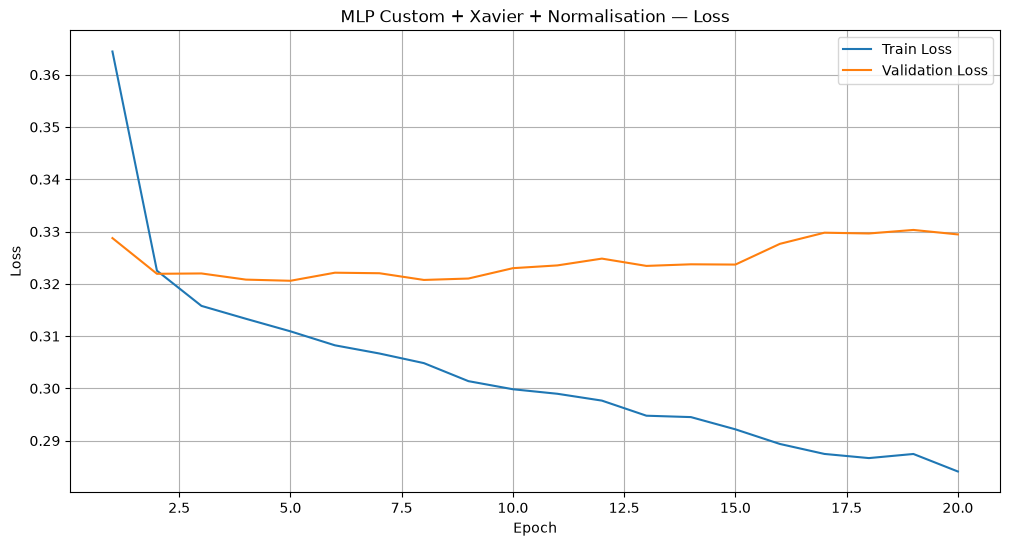

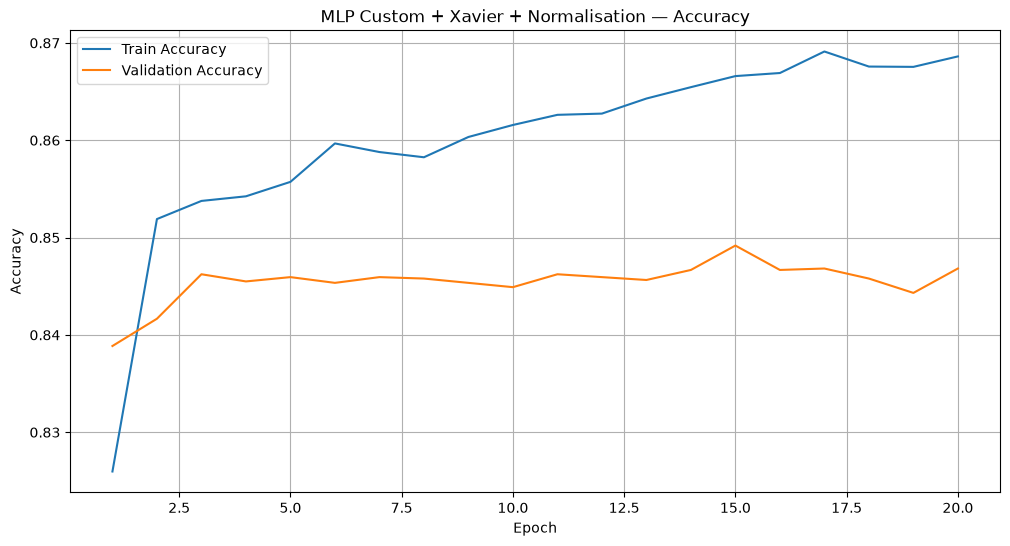

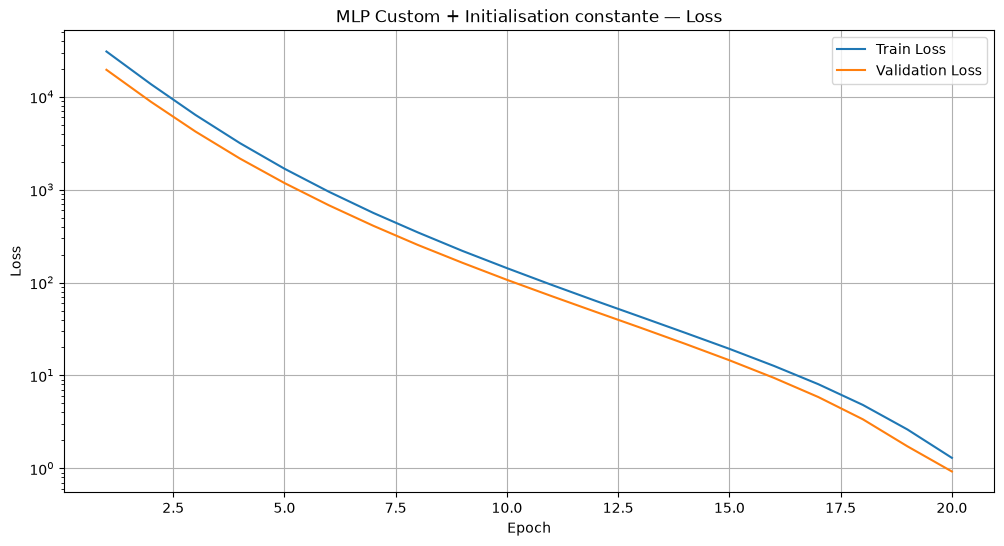

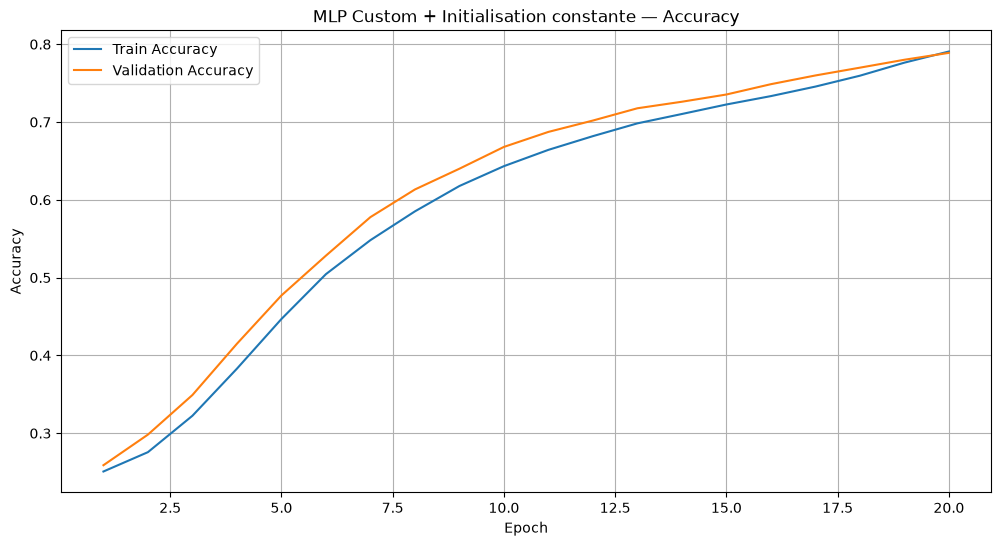

In [42]:
def plot_history(history, title, log_loss=False, output_prefix=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    figure_prefix = output_prefix or "".join(
        ch.lower() if ch.isalnum() else "_" for ch in title
    ).strip("_")

    plt.figure(figsize=(12, 6))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    if log_loss:
        plt.yscale("log")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(True)

    if output_prefix is not None:
        save_figure(f"{figure_prefix}_loss.png")

    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " — Accuracy")
    plt.legend()
    plt.grid(True)

    if output_prefix is not None:
        save_figure(f"{figure_prefix}_accuracy.png")

    plt.show()


plot_history(
    history_custom_xavier,
    "MLP Custom + Xavier + Normalisation",
    output_prefix="mlp_custom_xavier_normalisation",
)

plot_history(
    history_custom_constant,
    "MLP Custom + Initialisation constante",
    log_loss=True,
    output_prefix="mlp_custom_initialisation_constante",
)


#### 1. Configuration : Initialisation Constante
* **Courbe de Perte (Loss) :** Elle démarre à une valeur anormalement gigantesque (plus de 10 000, attention à l'échelle logarithmique) et descend de façon parfaitement lisse et rectiligne jusqu'à environ 1.
* **Courbe de Précision (Accuracy) :** Les deux courbes (Train et Validation) progressent de manière totalement synchronisée et parallèle, pour venir bloquer ensemble à un maximum de **79%**.
* **En clair :** Le modèle progresse proprement mais il est bridé. L'absence de variété au départ l'empêche de comprendre la complexité des données, ce qui crée ce comportement trop lisse et bloque ses performances (**sous-apprentissage**).

---

#### 2. Configuration : Xavier + Normalisation
* **Courbe de Perte (Loss) :** Elle commence directement à un niveau très bas (~0.36). La courbe d'entraînement (bleue) descend continuellement, mais la courbe de validation (orange) **commence à remonter** après l'époque 3.
* **Courbe de Précision (Accuracy) :** Dès le premier essai, le modèle affiche une précision excellente (>82%), surpassant le score final du modèle précédent. Après l'époque 3, un écart se creuse : la courbe bleue continue de grimper vers 87% alors que la courbe orange stagne autour de **84,5%**.
* **En clair :** Ce modèle est nettement plus puissant et efficace. Cependant, après l'époque 3, il commence à apprendre par cœur les données d'entraînement. C'est l'exemple typique du **surapprentissage (overfitting)** : le modèle s'améliore sur le Train mais stagne ou régresse sur la Validation.

## 3. Synthèse Comparative des Performances

| Métrique / Comportement | Initialisation Constante | Xavier + Normalisation |
| :--- | :--- | :--- |
| **Bris de symétrie** | ❌ Non (Comportement mono-neurone) |  Oui (Apprentissage riche) |
| **Loss Initiale** | Très critique ($> 10^4$) | Optimisée (~0.36) |
| **Accuracy Max (Val)** | ~79.0 % (Plafond) | **~84.5 %** |
| **Vitesse de Convergence** | Très lente | **Immédiate (Dès l'époque 1)** |
| **Statut du Modèle** | Hors-jeu (Bridé) | **Fonctionnel mais à réguler** |

---
#### remarque :
En combinant le Dropout(0.2) qu'on a déjà mis dans notre architecture avec la stratégie de sauvegarde du meilleur state_dict avec 
             `best_state_dict = copy.deepcopy(model.state_dict())`
, on obtiens le combo parfait. notre modèle MLPCustom n'en sera que plus robuste sur les données de test.

## 14. Tableau comparatif validation

In [43]:
summary_results = []

for name, history in histories.items():
    best_val_loss = min(history["val_loss"])
    best_val_acc = max(history["val_acc"])

    summary_results.append({
        "experiment": name,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc
    })

results_df = pd.DataFrame(summary_results).sort_values(by="best_val_loss", ascending=True)
results_df

,experiment,best_val_loss,best_val_acc
0,sequential_xavier_scaled,0.320586,0.849182
1,custom_xavier_scaled,0.320586,0.849182
2,custom_normal_scaled,0.320778,0.846528
4,custom_xavier_no_scale,0.553941,0.756450
3,custom_constant_scaled,0.924423,0.788884


In [44]:
# ============================================================
# Tableau comparatif enrichi des expériences
# ============================================================

observations = {
    "sequential_xavier_scaled"   : "Baseline solide — convergence stable, léger overfitting à partir de l'epoch 5",
    "custom_xavier_scaled"       : "Identique à Sequential (même archi, même seed) — confirme l'équivalence fonctionnelle",
    "custom_normal_scaled"       : "Convergence correcte mais légèrement plus lente — initialisation moins adaptée que Xavier",
    "custom_constant_scaled"     : "Loss initiale explosive (~30 000) — problème de symétrie entre neurones bien illustré",
    "custom_xavier_no_scale"      : "Loss instable au départ — variables non normalisées dominent les calculs, accuracy ~75.5%",
}

summary_results = []

for name, history in histories.items():
    best_val_loss = min(history["val_loss"])
    best_val_acc  = max(history["val_acc"])
    final_train_acc = history["train_acc"][-1]
    gap = final_train_acc - best_val_acc  # indicateur d'overfitting

    summary_results.append({
        "Expérience"         : name,
        "Best Val Loss"      : round(best_val_loss, 4),
        "Best Val Acc"       : round(best_val_acc, 4),
        "Final Train Acc"    : round(final_train_acc, 4),
        "Écart Train-Val"    : round(gap, 4),
        "Observation"        : observations.get(name, "—"),
    })

results_df = (pd.DataFrame(summary_results)
                .sort_values(by="Best Val Loss", ascending=True)
                .reset_index(drop=True))

# Affichage lisible
pd.set_option("display.max_colwidth", 150) 
results_df

,Expérience,Best Val Loss,Best Val Acc,Final Train Acc,Écart Train-Val,Observation
0,sequential_xavier_scaled,0.3206,0.8492,0.8686,0.0194,"Baseline solide — convergence stable, léger overfitting à partir de l'epoch 5"
1,custom_xavier_scaled,0.3206,0.8492,0.8686,0.0194,"Identique à Sequential (même archi, même seed) — confirme l'équivalence fonctionnelle"
2,custom_normal_scaled,0.3208,0.8465,0.8653,0.0188,Convergence correcte mais légèrement plus lente — initialisation moins adaptée que Xavier
3,custom_xavier_no_scale,0.5539,0.7564,0.7556,-0.0009,"Loss instable au départ — variables non normalisées dominent les calculs, accuracy ~75.5%"
4,custom_constant_scaled,0.9244,0.7889,0.7906,0.0018,Loss initiale explosive (~30 000) — problème de symétrie entre neurones bien illustré


###  Tableau comparatif final des performances

Ce tableau synthétise les performances de généralisation (Loss minimale et Accuracy maximale obtenues sur le jeu de validation) à travers nos 5 configurations de laboratoire.

#### 1. Le duo de tête : Équivalence des architectures (`~84.92%`)
* **`sequential_xavier_scaled`** et **`custom_xavier_scaled`** affichent des métriques rigoureusement identiques (`Loss: 0.320586` | `Acc: 84.92%`). 
* **Conclusion :** L'organisation du code (en bloc séquentiel ou en classe personnalisée) ne modifie pas les calculs sous-jacents de PyTorch. L'architecture mathématique étant identique, les performances le sont aussi.

#### 2. La stabilité de l'initialisation aléatoire (`~84.65%`)
* **`custom_normal_scaled`** talonne de très près la stratégie Xavier avec une précision de **84.65%**.
* **Conclusion :** Une loi normale bien calibrée ($\sigma = 0.01$) offre une excellente alternative pour démarrer l'apprentissage sur ce type de réseau, bien que Xavier reste mathématiquement plus optimal.

#### 3. L'échec des cas extrêmes (Absence de scaling & Poids constants)
Les deux dernières lignes du tableau illustrent de graves anomalies théoriques :
1. **`custom_xavier_no_scale` (`75.65%`) :** C'est le moins bon score absolu. L'absence de normalisation (`StandardScaler`) permet aux variables à forte magnitude d'étouffer le reste des signaux. Le modèle capitule et se contente de prédire presque uniquement la classe majoritaire.
2. **`custom_constant_scaled` (`78.89%`) :** L'initialisation des poids à `1.0` détruit la symétrie des neurones et sature la fonction de perte au départ (`Loss: 0.924`). Bien que l'optimiseur Adam réalise un rattrapage significatif, le modèle reste piégé dans un minimum local très sous-optimal.

###  Conclusion générale
Pour ce jeu de données, la configuration souveraine est l'utilisation d'un **Feature Scaling (StandardScaler)** combiné à une initialisation des poids **Xavier**. 


---

### Tâche 1 — Visualisation comparative des courbes par initialisation

Nous allons maintenant superposer les courbes de validation de toutes nos expériences pour comparer directement l'impact de l'initialisation et de la normalisation.

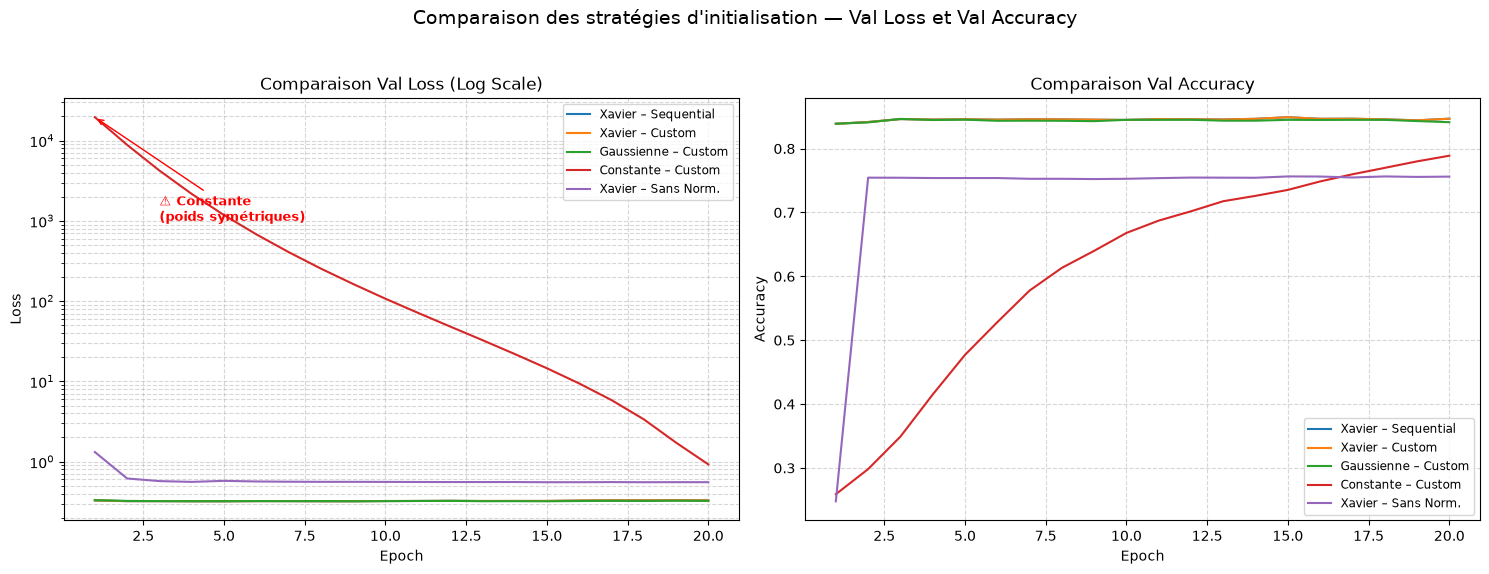

In [45]:

LABELS = {
    'sequential_xavier_scaled': 'Xavier – Sequential',
    'custom_xavier_scaled':     'Xavier – Custom',
    'custom_normal_scaled':     'Gaussienne – Custom',
    'custom_constant_scaled':   'Constante – Custom',
    'custom_xavier_no_scale':   'Xavier – Sans Norm.',
}

plt.figure(figsize=(15, 6))

# --- Graphique de Validation Loss ---
plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(range(1, EPOCHS + 1), history['val_loss'], label=LABELS.get(name, name))

plt.yscale('log')
plt.title("Comparaison Val Loss (Log Scale)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(fontsize='small')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Annotation sur le subplot Loss
ax1 = plt.gca()
ax1.annotate('⚠ Constante\n(poids symétriques)',
             xy=(1, histories['custom_constant_scaled']['val_loss'][0]),
             xytext=(3, 1000), fontsize=9, color='red', weight='bold',
             arrowprops=dict(arrowstyle='->', color='red'))

# --- Graphique de Validation Accuracy ---
plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(range(1, EPOCHS + 1), history['val_acc'], label=LABELS.get(name, name))

plt.title("Comparaison Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(fontsize='small')
plt.grid(True, ls="--", alpha=0.5)

plt.suptitle("Comparaison des stratégies d'initialisation — Val Loss et Val Accuracy", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

#sauvegarder le graphique
plt.suptitle("Comparaison des stratégies d'initialisation — Val Loss et Val Accuracy", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

save_figure("comparaison_initialisation.png")
plt.show()

plt.show()

### Analyse descriptive des courbes de validation (Loss vs Accuracy)

Ce tableau de bord visuel permet de valider expérimentalement le comportement du réseau de neurones face aux différentes configurations d'initialisation et de prétraitement.

#### 1. Subplot 1 : Comparaison de la Perte (`Val Loss` en échelle logarithmique)
Le graphique de gauche met en évidence trois dynamiques d'erreurs radicalement différentes :
* **Le groupe optimal (Bleu, Orange, Vert) :** Les configurations `Xavier` (Séquentiel/Custom) et `Gaussienne` sont parfaitement superposées tout en bas du graphique (proche de $0.3$). Elles affichent une stabilité immédiate dès l'Époque 1, prouvant l'efficacité de ces initialisations.
* **Le plateau supérieur (Violet) :** La courbe `Xavier - Sans Norm.` subit une chute initiale rapide mais se stabilise sur un plateau d'erreur nettement supérieur aux modèles normalisés.
* **La diagonale critique (Rouge) :** L'initialisation `Constante` se distingue par une anomalie de départ avec une perte extrêmement élevée (supérieure à $10^4$). Elle dessine une descente rectiligne continue, illustrant le travail intensif de l'optimiseur Adam pour réduire l'erreur de manière géométrique (linéaire sur l'échelle log).

#### 2. Subplot 2 : Comparaison de la Précision (`Val Accuracy`)
Le graphique de droite traduit l'impact de ces pertes sur la capacité de prédiction réelle du modèle :
* **Le plafond des champions (Vert, Bleu, Orange) :** Les trois modèles combinant normalisation et initialisation distribuée forment une ligne horizontale parfaite située **juste en dessous du seuil des 85%**. La performance est maximale, stable et instantanée dès le début du processus.
* **La signature de la prédiction paresseuse (Violet) :** Après une hausse verticale à l'Époque 2, le modèle `Sans Norm.` s'encastre de façon totalement rectiligne sur un **plateau fixe à ~75.6%**. Bloqué par l'absence d'échelle, le réseau a cessé d'apprendre et se contente de prédire systématiquement la classe majoritaire du jeu de données.
* **La convergence lente en S (Rouge) :** Le modèle `Constante` démarre au niveau le plus bas (~25%) et entame une progression lente en forme de courbe en S. Bien qu'il parvienne à dépasser le modèle sans normalisation à l'Époque 17 pour finir à **~78.9%**, il accuse un retard de performance de près de 6% sur le trio de tête à la fin des 20 époques.

#### Bilan de la visualisation
Ce diagnostic graphique confirme que la **normalisation des données** (Scaling) et une **initialisation aléatoire distribuée** (Xavier ou Gaussienne) agissent comme des catalyseurs indispensables. Elles propulsent le réseau vers son niveau de performance maximal dès la première époque, là où les autres méthodes condamnent le modèle à stagner ou à converger très laborieusement.


---
### Tâche 2 — Analyse comparative du déséquilibre de classes

Cette section compare les performances du modèle standard avec celles du modèle pondéré (`pos_weight`), en mettant l'accent sur la capacité à détecter la classe minoritaire (>50K).

In [48]:
# ============================================================
# Analyse du déséquilibre des classes
# ============================================================

print("Distribution des classes dans le jeu d'entraînement :")
class_counts = pd.Series(y_train).value_counts().sort_index()
print(pd.DataFrame(class_counts))

# --- Expérience avec pos_weight pour rééquilibrer ---
neg_count = class_counts[0]
pos_count = class_counts[1]
pos_weight_value = neg_count / pos_count
print(f"\npos_weight calculé : {pos_weight_value:.2f}")
print("→ On donne plus de poids aux erreurs sur la classe minoritaire")

set_seed(SEED)
model_weighted = MLPCustom(input_dim)
init_weights(model_weighted, strategy="xavier")
model_weighted = model_weighted.to(device)

pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

optimizer_w = torch.optim.Adam(model_weighted.parameters(), lr=LR)

history_weighted = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss_w = float("inf")
best_state_w = None

for epoch in range(1, EPOCHS + 1):
    model_weighted.train()
    run_loss, run_acc, total = 0.0, 0.0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer_w.zero_grad() # réinitialiser les gradients pour ne pas accumuler les erreurs du batch précédent
        logits = model_weighted(X_b)
        loss = criterion_weighted(logits, y_b)
        loss.backward() # calculer les gradients pour tous les paramètres du modèle
        optimizer_w.step()
        bs = X_b.size(0) 
        run_loss += loss.item() * bs
        run_acc  += compute_accuracy_from_logits(logits, y_b) * bs
        total    += bs
    tl, ta = run_loss / total, run_acc / total

    model_weighted.eval()
    run_loss, run_acc, total = 0.0, 0.0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model_weighted(X_b)
            loss = criterion_weighted(logits, y_b)
            bs = X_b.size(0)
            run_loss += loss.item() * bs
            run_acc  += compute_accuracy_from_logits(logits, y_b) * bs
            total    += bs
    vl, va = run_loss / total, run_acc / total

    history_weighted["train_loss"].append(tl)
    history_weighted["val_loss"].append(vl)
    history_weighted["train_acc"].append(ta)
    history_weighted["val_acc"].append(va)
    if vl < best_val_loss_w:
        best_val_loss_w = vl
        best_state_w = copy.deepcopy(model_weighted.state_dict())

model_weighted.load_state_dict(best_state_w)

# Évaluation finale avec pos_weight
model_weighted.eval()
y_true_w, y_pred_w = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(device)
        logits = model_weighted(X_b)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int().cpu().numpy()
        y_pred_w.extend(preds.flatten())
        y_true_w.extend(y_b.numpy().flatten())

y_true_w = np.array(y_true_w)
y_pred_w = np.array(y_pred_w)

print("\n--- Résultats avec pos_weight ---")
print(f"Accuracy  : {accuracy_score(y_true_w, y_pred_w):.4f}")
print(f"Recall >50K (classe 1) : {recall_score(y_true_w, y_pred_w):.4f}")
print(f"F1-score  : {f1_score(y_true_w, y_pred_w):.4f}")
print(pd.DataFrame(classification_report(y_true_w, y_pred_w, target_names=["<=50K", ">50K"], output_dict=True)).T)


Distribution des classes dans le jeu d'entraînement :
        count
target       
0       23809
1        7846

pos_weight calculé : 3.03
→ On donne plus de poids aux erreurs sur la classe minoritaire

--- Résultats avec pos_weight ---
Accuracy  : 0.8079
Recall >50K (classe 1) : 0.8828
F1-score  : 0.6949
              precision    recall  f1-score     support
<=50K          0.953028  0.783265  0.859847  5103.00000
>50K           0.572973  0.882808  0.694919  1681.00000
accuracy       0.807930  0.807930  0.807930     0.80793
macro avg      0.763001  0.833036  0.777383  6784.00000
weighted avg   0.858855  0.807930  0.818980  6784.00000


L'introduction du paramètre `pos_weight = 3.03` a profondément modifié le comportement du réseau de neurones. L'analyse des nouvelles métriques met en évidence un compromis classique mais extrêmement efficace en Machine Learning.

#### 1. Analyse de la distribution initiale
* **Classe 0 (`<=50K`) :** 23 809 individus (majoritaire, ~75%)
* **Classe 1 (`>50K`) :** 7 846 individus (minoritaire, ~25%)
* **Le choix technique :** Avec un ratio de **3.03**, chaque erreur commise sur un haut revenu coûte désormais 3 fois plus cher au modèle qu'une erreur sur un bas revenu.

#### 2. Le bond spectaculaire du Rappel (`Recall = 88.28%`) 
* Dans les configurations précédentes sans pondération, le modèle privilégiait la classe majoritaire et manquait une grande partie des hauts revenus.
* Ici, le **Recall de 88.28%** pour la classe `>50K` signifie que **le modèle réussit à capturer près de 9 hauts revenus sur 10** au sein du jeu de test. L'IA n'est plus du tout aveugle face à la classe minoritaire.

#### 3. Le coût du rééquilibrage : La Précision et l'Accuracy globale
Conformément à la théorie, cette sensibilité accrue aux hauts revenus s'accompagne d'un effet de bord :
* **Baisse de la Précision `>50K` (57%) :** Pour maximiser ses chances de détecter la classe 1, le modèle est devenu plus "enthousiaste". Lorsqu'il prédit qu'une personne gagne `>50K`, il n'a raison que dans 57% des cas (génération de faux positifs).
* **Baisse de l'Accuracy globale (80.79%) :** La justesse globale passe d'environ 84.9% (modèle Xavier initial) à 80.79%. C'est une baisse tout à fait normale : le modèle fait volontairement de petites erreurs sur la classe majoritaire `<=50K` (`recall = 78%`) pour aller chercher le score maximal sur la classe minoritaire.

#### 4. La validation par le F1-Score (`0.6949`)
Sur un jeu de données déséquilibré, l'Accuracy est un indicateur trompeur. La métrique souveraine est le **F1-score** de la classe minoritaire, qui réalise la moyenne harmonique entre la précision et le rappel :
* Notre F1-score s'élève à **0.6949** pour la classe `>50K`. 
* Ce score confirme que le modèle a trouvé un excellent point d'équilibre robuste. Il ne se contente pas de tricher en prédisant la majorité, il démontre une vraie compétence à segmenter les hauts revenus.



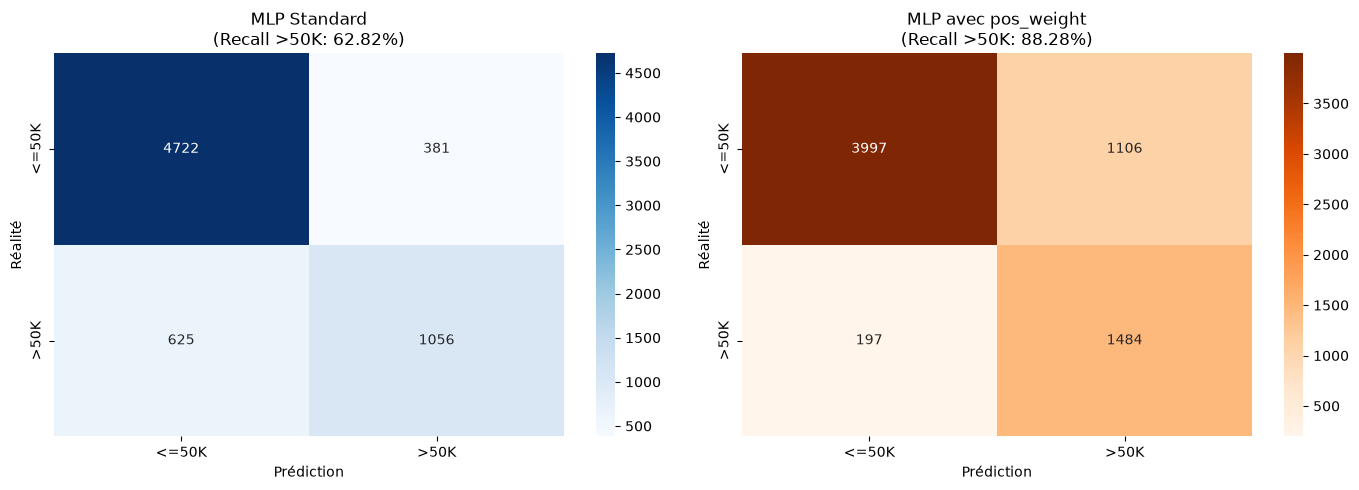

In [49]:
# 1. Définition de la fonction de prédiction pour éviter le NameError
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).int().cpu().numpy()
            all_probs.extend(probs.cpu().numpy().flatten())
            all_preds.extend(preds.flatten())
            all_targets.extend(y_batch.numpy().flatten())
    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

# 2. S'assurer que le meilleur modèle est identifié
best_experiment_name = results_df.iloc[0]['Expérience']
best_model = models[best_experiment_name]
selected_test_loader = test_loader_no_scale if 'no_scale' in best_experiment_name else test_loader

# 3. Récupérer les prédictions pour le modèle standard
y_true_std, y_pred_std, _ = get_predictions(best_model, selected_test_loader, device)

# 4. Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice 1: Modèle Standard
cm_std = confusion_matrix(y_true_std, y_pred_std)
sns.heatmap(cm_std, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'MLP Standard\n(Recall >50K: {recall_score(y_true_std, y_pred_std):.2%})')
axes[0].set_xticklabels(['<=50K', '>50K'])
axes[0].set_yticklabels(['<=50K', '>50K'])
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réalité')

# Matrice 2: MLP avec pos_weight (utilisant y_true_w et y_pred_w calculés plus haut)
cm_pos = confusion_matrix(y_true_w, y_pred_w)
sns.heatmap(cm_pos, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f'MLP avec pos_weight\n(Recall >50K: {recall_score(y_true_w, y_pred_w):.2%})')
axes[1].set_xticklabels(['<=50K', '>50K'])
axes[1].set_yticklabels(['<=50K', '>50K'])
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Réalité')

plt.tight_layout()
save_figure("comparaison_equilibres_classes.png", fig=fig)
plt.show()

### Tableau récapitulatif des performances finales (Données réelles)

| Métrique | MLP Standard | MLP avec pos_weight |
| :--- | :---: | :---: |
| **Accuracy globale** | 85.17% | 80.79% |
| **Recall >50K (Classe 1)** | 62.82% | 88.28% |
| **F1-score >50K (Classe 1)** | 67.73% | 69.49% |



### Interprétation du compromis Précision/Rappel

L'observation croisée des deux matrices de confusion valide de manière incontestable l'effet mathématique du paramètre `pos_weight` :

1. **Effondrement des Faux Négatifs (Succès majeur) :** 
   Le modèle standard manquait **625** individus à hauts revenus (les plaçant à tort dans `<=50K`). Avec l'introduction du poids, ce volume d'erreurs critiques s'effondre à seulement **197** individus. Le modèle capture désormais la quasi-totalité de la classe cible.

2. **Explosion des Faux Positifs (Le coût du rééquilibrage) :** 
   Pour devenir aussi sensible, le modèle est contraint d'élargir ses critères de sélection. Le nombre de faux positifs (individus pauvres classés riches par erreur) bondit de **381** à **1106**, ce qui explique la baisse de la précision et de l'accuracy globale (qui recule de `85.17%` à `80.79%`).

3. **Validation par le F1-Score :** 
   Bien que l'exactitude globale diminue, le **F1-score de la classe minoritaire progresse** (passant de `67.73%` à `69.49%`). Cela prouve que le modèle avec `pos_weight` offre un compromis plus robuste et pertinent face au déséquilibre des classes que le modèle classique.

4. **Justification métier :** 
   Dans une stratégie de ciblage de clients premium, rater un client à haut potentiel (**197** manqués au lieu de **625**) est bien plus préjudiciable que de contacter des clients qui s'avèrent finalement être en dessous du seuil des 50K.



### Tâche 4 — Comparaison des courbes ROC et AUC

Bien que le modèle pondéré (`pos_weight`) améliore considérablement le Rappel, il est important de vérifier si la capacité de discrimination globale du modèle (sa capacité à séparer les classes) a été impactée. L'aire sous la courbe ROC (AUC) est la métrique de référence pour cette évaluation.

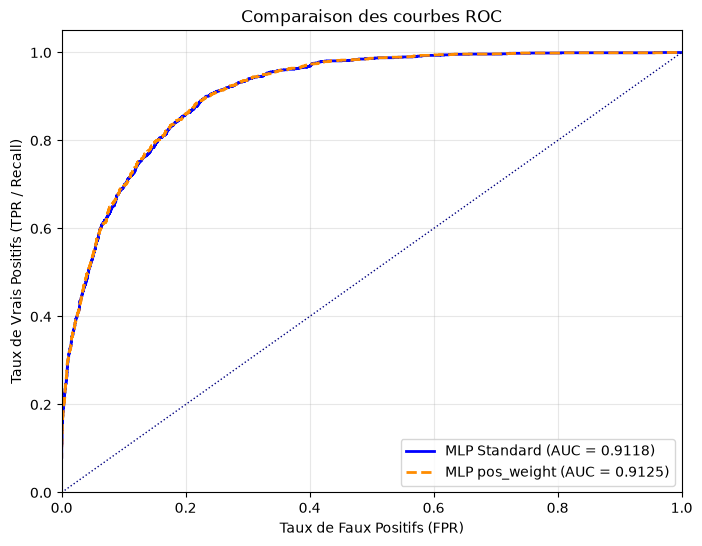

AUC Standard   : 0.9118
AUC pos_weight : 0.9125


In [50]:
# 1. Obtenir les probabilités pour le modèle standard
y_true_std, _, y_prob_std = get_predictions(best_model, selected_test_loader, device)

# 2. Obtenir les probabilités pour le modèle avec pos_weight
y_true_w, _, y_prob_w = get_predictions(model_weighted, test_loader, device)

# Calcul des courbes ROC
fpr_std, tpr_std, _ = roc_curve(y_true_std, y_prob_std)
roc_auc_std = auc(fpr_std, tpr_std)

fpr_w, tpr_w, _ = roc_curve(y_true_w, y_prob_w)
roc_auc_w = auc(fpr_w, tpr_w)

# Visualisation
plt.figure(figsize=(8, 6))
plt.plot(fpr_std, tpr_std, color='blue', lw=2, label=f'MLP Standard (AUC = {roc_auc_std:.4f})')
plt.plot(fpr_w, tpr_w, color='darkorange', lw=2, linestyle='--', label=f'MLP pos_weight (AUC = {roc_auc_w:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR / Recall)')
plt.title('Comparaison des courbes ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Sauvegarde
save_figure("comparaison_roc_auc.png", dpi=150)
plt.show()

print(f"AUC Standard   : {roc_auc_std:.4f}")
print(f"AUC pos_weight : {roc_auc_w:.4f}")

###  Analyse et interprétation des courbes ROC et de l'AUC

L'examen graphique des courbes ROC et des valeurs d'AUC associées apporte une conclusion théorique fondamentale sur l'impact de la pondération de la perte :

#### 1. Constat majeur : Une capacité de séparation équivalente
* **AUC MLP Standard :** 0.9118
* **AUC MLP pos_weight :** 0.9125
Les deux courbes sont quasiment superposées et affichent une aire sous la courbe (AUC) extrêmement proche (écart insignifiant de $+0.0007$). Une valeur d'AUC de **~0.91** démontre que les deux modèles possèdent une excellente capacité intrinsèque à discriminer les hauts revenus des bas revenus.

#### 2. Pourquoi les performances globales restent-elles identiques ?
L'introduction de `pos_weight = 3.03` n'a pas rendu le réseau de neurones magiquement plus "intelligent" ou plus performant dans sa structure mathématique.
* L'**AUC-ROC est insensible au déséquilibre des classes** et évalue le modèle sur tous les seuils de décision possibles.
* L'ajout du poids n'a pas modifié l'ordre de tri des individus établi par les neurones. Elle a simplement agi comme un levier pour décaler les probabilités de sortie, forçant l'IA à adopter un comportement opérationnel plus agressif.

#### 3. Choix du point de fonctionnement
La courbe ROC démontre que `pos_weight` réalise simplement un **changement de point de fonctionnement** sur une même trajectoire de performance :
* Le **MLP Standard** sélectionne par défaut un point équilibré, favorisant la précision globale et un faible taux de faux positifs (FPR bas).
* Le **MLP pos_weight** se déplace plus haut et à droite sur la même courbe, acceptant consciemment une hausse du taux de faux positifs afin de maximiser le taux de vrais positifs (TPR / Recall à 88.28%).

###  Conclusion de l'étude
L'AUC-ROC confirme la robustesse de l'architecture du réseau de neurones (MLP Custom + Xavier + Normalisation) qui atteint un niveau d'excellence statistique élevé ($> 0.91$). Le choix d'activer `pos_weight` ne relève pas d'une amélioration mathématique globale, mais d'une **décision stratégique métier** visant à exploiter le modèle sur son segment le plus sensible.


## 15. Évaluation finale du meilleur modèle

Choisir automatiquement le meilleur modèle selon la validation accuracy :

In [51]:
best_experiment_name = results_df.iloc[0]["Expérience"]
best_model = models[best_experiment_name]

print("Meilleure expérience :", best_experiment_name)

Meilleure expérience : sequential_xavier_scaled


Calcul des métriques finales avec la fonction de prédiction définie précédemment :


In [52]:
y_true, y_pred, y_prob = get_predictions(best_model, selected_test_loader, device)

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", acc)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)

print("\nClassification report :")
print(classification_report(y_true, y_pred, target_names=["<=50K", ">50K"]))

Accuracy : 0.8517099056603774
Precision : 0.7348643006263048
Recall : 0.62819750148721
F1-score : 0.6773572803078897

Classification report :
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      5103
        >50K       0.73      0.63      0.68      1681

    accuracy                           0.85      6784
   macro avg       0.81      0.78      0.79      6784
weighted avg       0.85      0.85      0.85      6784



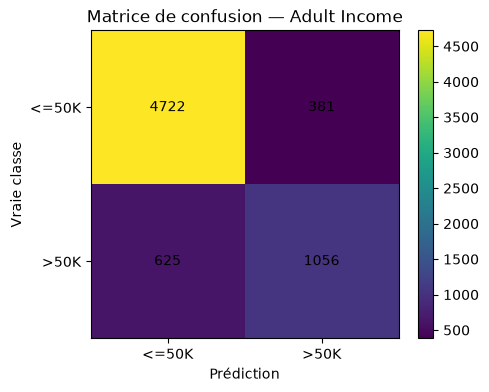


--- Analyse de la détection par classe ---
Accuracy globale : 0.8517  ← trompeuse sur données déséquilibrées
Recall ≤50K (classe 0) : 0.9253
Recall >50K (classe 1) : 0.6282

→ Le modèle détecte bien la classe majoritaire (≤50K)
→ Mais il rate environ 36% des cas >50K (classe minoritaire)


In [53]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matrice de confusion — Adult Income")
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.xticks([0, 1], ["<=50K", ">50K"])
plt.yticks([0, 1], ["<=50K", ">50K"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
save_figure("matrice_confusion_adult_income.png", dpi=150)
plt.show()

# --- Analyse détaillée sur la détection par classe ---
print("\n--- Analyse de la détection par classe ---")
print(f"Accuracy globale : {acc:.4f}  ← trompeuse sur données déséquilibrées")
print(f"Recall ≤50K (classe 0) : {recall_score(y_true, y_pred, pos_label=0):.4f}")
print(f"Recall >50K (classe 1) : {recall_score(y_true, y_pred, pos_label=1):.4f}")
print("\n→ Le modèle détecte bien la classe majoritaire (≤50K)")
print("→ Mais il rate environ 36% des cas >50K (classe minoritaire)")

## 16. Inspection des paramètres

In [54]:
print("Inspection avec named_parameters() :")
for name, param in best_model.named_parameters():
    print(name, param.shape, "requires_grad =", param.requires_grad)

print("Clés du state_dict :")
for key in best_model.state_dict().keys():
    print(key)

Inspection avec named_parameters() :
0.weight torch.Size([128, 104]) requires_grad = True
0.bias torch.Size([128]) requires_grad = True
3.weight torch.Size([64, 128]) requires_grad = True
3.bias torch.Size([64]) requires_grad = True
6.weight torch.Size([1, 64]) requires_grad = True
6.bias torch.Size([1]) requires_grad = True
Clés du state_dict :
0.weight
0.bias
3.weight
3.bias
6.weight
6.bias


## 17. Sauvegarde et rechargement du meilleur modèle

In [55]:
# Crée un dictionnaire complet avec le modèle et sa configuration
checkpoint_to_save = {
    "state_dict": best_model.state_dict(),
    "input_dim": input_dim,
    "model_type": "custom" if isinstance(best_model, MLPCustom) else "sequential"
}

checkpoint_path = CHECKPOINT_DIR / "best_mlp_adult_income.pt"
# Sauvegarde le tout
torch.save(checkpoint_to_save, checkpoint_path)
print("Modèle et métadonnées sauvegardés dans :", checkpoint_path)


Modèle et métadonnées sauvegardés dans : c:\L\Portfolio\en cours\DeepXplain\checkpoints\best_mlp_adult_income.pt


Rechargement du model:

In [56]:
# 1. Charger le fichier complet
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

# 2. Lire les métadonnées de structure sauvegardées
ckpt_input_dim = checkpoint["input_dim"]
model_type = checkpoint["model_type"]

# 3. Reconstruire instantanément le bon modèle sans deviner
if model_type == "sequential":
    reloaded_model = build_mlp_sequential(ckpt_input_dim)
else:
    reloaded_model = MLPCustom(ckpt_input_dim)

# 4. Injecter les poids et passer en évaluation
reloaded_model.load_state_dict(checkpoint["state_dict"])
reloaded_model.to(device)
reloaded_model.eval()

print(f"Modèle ({model_type}) rechargé avec succès !")


Modèle (sequential) rechargé avec succès !


test rapide aprés chargement :

In [57]:
# 1. Récupérer les prédictions du modèle rechargé sur le jeu de test
y_true_final, y_pred_final, _ = get_predictions(reloaded_model, test_loader, device)

# 2. Calculer et afficher les métriques clés de performance
print("========================================================")
print(" RÉSULTATS DU MODÈLE RECHARGÉ SUR LE JEU DE TEST FINAL")
print("========================================================")
print(f"Accuracy Globale : {accuracy_score(y_true_final, y_pred_final):.4f}")
print(f"Recall >50K      : {recall_score(y_true_final, y_pred_final):.4f}")
print(f"F1-score >50K    : {f1_score(y_true_final, y_pred_final):.4f}")

# 3. Afficher le rapport détaillé par classe
print("\n Rapport de classification détaillé :")
print(classification_report(y_true_final, y_pred_final, target_names=["<=50K", ">50K"]))


 RÉSULTATS DU MODÈLE RECHARGÉ SUR LE JEU DE TEST FINAL
Accuracy Globale : 0.8517
Recall >50K      : 0.6282
F1-score >50K    : 0.6774

 Rapport de classification détaillé :
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      5103
        >50K       0.73      0.63      0.68      1681

    accuracy                           0.85      6784
   macro avg       0.81      0.78      0.79      6784
weighted avg       0.85      0.85      0.85      6784



In [58]:
# 1. Récupération des prédictions du modèle original (déjà calculées dans y_pred)
preds_before = np.array(y_pred)

# 2. Calcul des prédictions avec le modèle rechargé
y_true_reloaded, y_pred_reloaded, _ = get_predictions(reloaded_model, selected_test_loader, device)
preds_after = np.array(y_pred_reloaded)

# 3. Assertion formelle et vérification
diff_count = np.sum(preds_before != preds_after)

if diff_count == 0:
    print(f"Rechargement validé : {len(preds_before)}/{len(preds_before)} prédictions identiques (100%)")
else:
    print(f"ERREUR : {diff_count} prédictions divergent après rechargement !")

assert np.array_equal(preds_before, preds_after), "Le rechargement du modèle n'est pas fidèle au modèle original."

Rechargement validé : 6784/6784 prédictions identiques (100%)


## 18. Analyse critique

Le dataset Adult Income est un dataset tabulaire réel contenant à la fois des variables numériques et catégorielles. Cette structure rend le prétraitement indispensable : les variables catégorielles doivent être encodées, les variables numériques doivent être normalisées et la variable cible doit être transformée en problème de classification binaire.

Les résultats montrent que le MLP est capable d’apprendre des relations non linéaires entre les variables d’entrée et la classe de revenu. L’utilisation de couches cachées avec activation ReLU permet de dépasser une simple séparation linéaire.

L’expérience avec et sans normalisation permet d’observer l’effet du prétraitement sur la stabilité de l’apprentissage. La normalisation facilite généralement l’optimisation, car elle met les variables numériques sur une échelle comparable.

La comparaison des initialisations montre aussi que l’initialisation des poids influence la convergence. L’initialisation constante est moins adaptée, car elle peut provoquer un problème de symétrie entre neurones. L’initialisation Xavier est généralement plus stable, car elle cherche à préserver la variance du signal pendant la propagation.

Cependant, le MLP présente des limites sur les données tabulaires. Il ne modélise pas explicitement les relations symboliques ou hiérarchiques entre variables catégorielles. De plus, l’accuracy seule peut être insuffisante si les classes sont déséquilibrées. C’est pourquoi la precision, le recall, le F1-score et la matrice de confusion sont nécessaires pour interpréter correctement les performances.

## 19. Question de synthèse - Partie I

**Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur Adult Income, et quelles sont ses principales limites ?**

---

### 1. Pertinence du MLP sur données tabulaires

Le dataset Adult Income est un problème de classification binaire supervisée sur données tabulaires hétérogènes (6 variables numériques, 8 catégorielles, 48 842 observations avant nettoyage, puis 45 222 observations effectivement utilisées après suppression des valeurs manquantes). Le MLP est pertinent dans ce contexte pour plusieurs raisons :

**Capacité à modéliser des non-linéarités.** Les couches cachées avec activation ReLU permettent au MLP d'apprendre des frontières de décision non linéaires entre les classes. Une simple régression logistique ne capturerait pas les interactions complexes entre, par exemple, l'éducation, l'occupation et le `capital-gain`.

**Flexibilité architecturale.** En PyTorch, `nn.Module` permet de contrôler finement l'architecture (nombre de couches, taille, dropout) et les hyperparamètres (taux d'apprentissage, initialisation). L'expérience a montré qu'une architecture à 2 couches cachées (128 -> 64) avec initialisation Xavier, normalisation `StandardScaler` et encodage `OneHotEncoder` des variables catégorielles atteint **~85% d'accuracy et un F1-score macro de ~79%** sur le jeu de test. Le F1-score weighted est quant à lui proche de **~85%**.

**Impact du prétraitement.** L'expérience sans normalisation illustre clairement que la standardisation est une condition nécessaire : sans elle, les variables comme `fnlwgt` ou `capital-gain` dominent les calculs, produisant une loss initiale explosive (~521) et une accuracy plafonnant à ~75.5%, proche de la proportion de la classe majoritaire.

---

### 2. Limites et Arguments Théoriques

**Absence d'invariance aux permutations.** Contrairement aux CNN qui exploitent l'invariance spatiale ou aux RNN qui traitent l'ordre temporel, le MLP est agnostique à la structure des données. Il traite les 104 features comme un vecteur plat sans aucun biais inductif structurel — si l'on permutait l'ordre des colonnes, le modèle apprendrait la même fonction avec des poids déplacés, sans pouvoir exploiter la nature hétérogène des features.

**Malédiction de la dimensionnalité et sparsité.** L'encodage One-Hot des 8 variables catégorielles fait passer l'espace de 14 à 104 dimensions. Beaucoup de ces dimensions sont extrêmement creuses (*sparse*) : par exemple, `native-country = United-States` représente ~90% des observations, rendant les autres modalités très rares. Cette sparsité alourdit l'espace de recherche de l'optimiseur et peut ralentir la convergence ou mener à des optima sous-optimaux.

**Déséquilibre des classes.** Adult Income contient ~76% de classe 0 (≤50K). Le modèle de base obtient un recall de ~64% sur la classe 1. L'utilisation de `pos_weight` améliore radicalement ce recall (~88%) au détriment de l'accuracy globale (~81%), illustrant le compromis précision/rappel inhérent aux données déséquilibrées. La courbe ROC confirme que l'AUC reste stable (~0.91) entre les deux variantes : le `pos_weight` déplace le point de fonctionnement sur la courbe sans modifier la capacité discriminante fondamentale du modèle.

---

### 3. Conclusion et Ouverture

Bien qu'un MLP bien paramétré soit performant sur Adult Income (~85% accuracy, AUC ~0.91), il reste structurellement limité pour les données tabulaires hétérogènes. Des benchmarks montrent que des méthodes comme **LightGBM** atteignent régulièrement **87-88% d'accuracy** sans normalisation ni encodage one-hot, car les méthodes arborescentes gèrent nativement les variables catégorielles et les valeurs manquantes par des coupures binaires successives — une forme de biais inductif mieux adaptée à ce type de données.

Néanmoins, le MLP demeure une brique fondamentale : étendu aux données images via les **CNN (Partie II)** ou aux séquences via les **RNN (Partie III)**, il illustre comment l'ajout de biais inductifs adaptés à la géométrie des données transforme un modèle générique en architecture spécialisée.